In [1]:
from itertools import product
import psutil
from functools import partial
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import os
import matplotlib.pyplot as plt
from glob import glob
import seaborn as sns 
from tqdm.notebook import tqdm
from matplotlib import font_manager
import scipy.stats as stats

font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})

# GMJ plot ideas
- Deviation from standard LUCJ (CCSD t1/t2 amps)
- Deviation of all initializations from HCI? (Maybe useless for this case; see point 1)
- Something to highlight SQDs "robustness" regarding initialization
    - Deviation from standard LUCJ (CCSD t1/t2 amps) but use barplot and explicitly highlight the GDB cases larger than 20 orbitals (see Kevin Sung where they mention initializations beyond 30 orbitals)
    - Boxplot deviations where the y-axis is deviations, x-axis is the basis set and the hue is the injection type

In [2]:
energyDF=pd.read_csv("../../../classical/energies.csv",index_col=0)
moldf = pd.read_csv('molecules.csv')
activespacedf = pd.read_csv("active_spaces.csv")

In [3]:
import re

def process_list(data_list):
    """
    Processes a list of strings to perform the following operations:
    1.  Strips trailing newline characters.
    2.  Parses the 'LUCJ' string into three separate elements.
    3.  Converts the final element from a string to a float.
    """
    processed_list = []
    for item in data_list:
        item = item.strip()

        if "LUCJ" in item:
            # Use a regular expression to extract the components
            match = re.search(r'(LUCJ)\(L=(.*?)\)/(.*)', item)
            if match:
                processed_list.extend(match.groups())
            else:
                processed_list.append(item)
        else:
            processed_list.append(item)
    
    # Convert the last element to a float
    # We use a try-except block in case the last element is not a number
    try:
        processed_list[-1] = float(processed_list[-1])
    except (ValueError, IndexError):
        pass # The last element is not a float, so we ignore it

    return processed_list

In [4]:
postprocessed = []
for i in tqdm(glob("./energies/*txt"),desc='Running'):
    with open(i,'r') as f:
        lines = f.readlines()

    try:  
        moldict = pd.DataFrame.from_dict(dict(zip(["Basis Set","Molecule","Method","L","Injected","Energy"],process_list(lines))),orient='index').T
        moldict.astype({'L':int,"Energy":float})
        postprocessed.append(moldict)
    except:
        print(i)
        # print(e)

Running:   0%|          | 0/1080 [00:00<?, ?it/s]

In [5]:
LUCJDF=pd.concat(postprocessed).reset_index().drop(columns=['index']).astype({"L":int,"Energy":float})
LUCJDF['Method'] =[f"LUCJ(L={i})" for i in LUCJDF['L']]

In [6]:
# LUCJDF[LUCJDF['Energy']<-1e3].to_excel("repostprocess.xlsx")

In [7]:
uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueMol = LUCJDF['Molecule'].unique()
uniqueInj = LUCJDF['Injected'].unique()
uniqueLayers = LUCJDF['L'].unique()
uniqueMethods = np.hstack([LUCJDF['Method'].sort_values().unique(),energyDF['Method'].unique()])

# Deviation from CCSD initialized

In [8]:
for basis, layer, mol in product(uniqueBasis,uniqueLayers,uniqueMol):
    mask = ((LUCJDF['Basis Set']==basis) &
            (LUCJDF['L']==layer) &
            (LUCJDF['Molecule']==mol) 
           
           )
    print(mol,basis)
    LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - LUCJDF.loc[mask&(LUCJDF['Injected']=='CCSD'),'Energy'].values)*1e3
    # try:
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3
    # except:
    #     mol = moldf.loc[moldf['molecule'] == mol,'mol_filename'].values[0].replace('.xyz','')
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3

ammonia STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
but-1-yne STO-3G
water STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
fluoroform STO-3G
methane STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
formaldehyde STO-3G
ammonia STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
but-1-yne STO-3G
water STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
fluoroform STO-3G
methane STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
formaldehyde STO-3G
ammonia STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
but-1-yne STO-3G
water STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
fluoroform STO-3G
methane STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
formaldehyde STO-3G
ammonia STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
but-1-yne STO-3G
water STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
fluoroform STO-3G
methane STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
formaldehyde STO-3G
ammonia STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
but-1-yne STO-3G
water STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
fluorof

In [51]:
LUCJDF.loc[LUCJDF['Deviation'].idxmax()]

Basis Set        aug-cc-pVDZ
Molecule      buta-1,3-diene
Method             LUCJ(L=1)
L                          1
Injected              random
Energy           -154.428468
Deviation    78542075.245929
n_atoms                   10
Name: 81, dtype: object

In [9]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4,
    "prop-2-en-1-ol":10,
    "but-1-yne":10,
    "fluoroform":5,
    "buta-1,3-diene":10,
    "(Z)-1-fluoroprop-1-ene":9
}

LUCJDF['n_atoms'] = LUCJDF['Molecule'].map(n_atoms_dict)

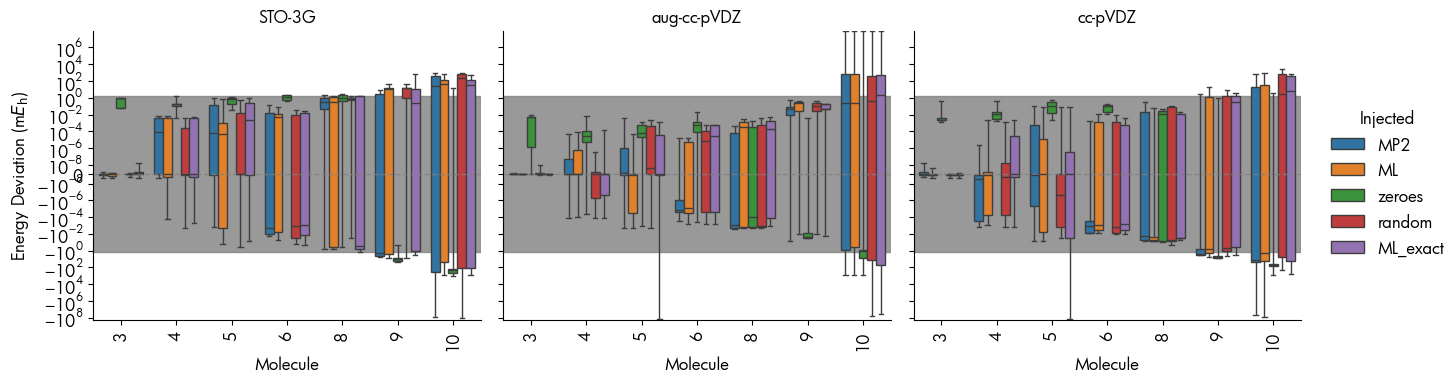

In [10]:
g = sns.catplot(LUCJDF[LUCJDF['Injected']!='CCSD'],
                col='Basis Set',
                # col='L',
                x='n_atoms',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.1 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()

In [ ]:
uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueMol = LUCJDF['Molecule'].unique()
uniqueInj = LUCJDF['Injected'].unique()
uniqueLayers = LUCJDF['L'].unique()


array(['ML', 'MP2', 'ML_exact', 'random', 'zeroes'], dtype=object)

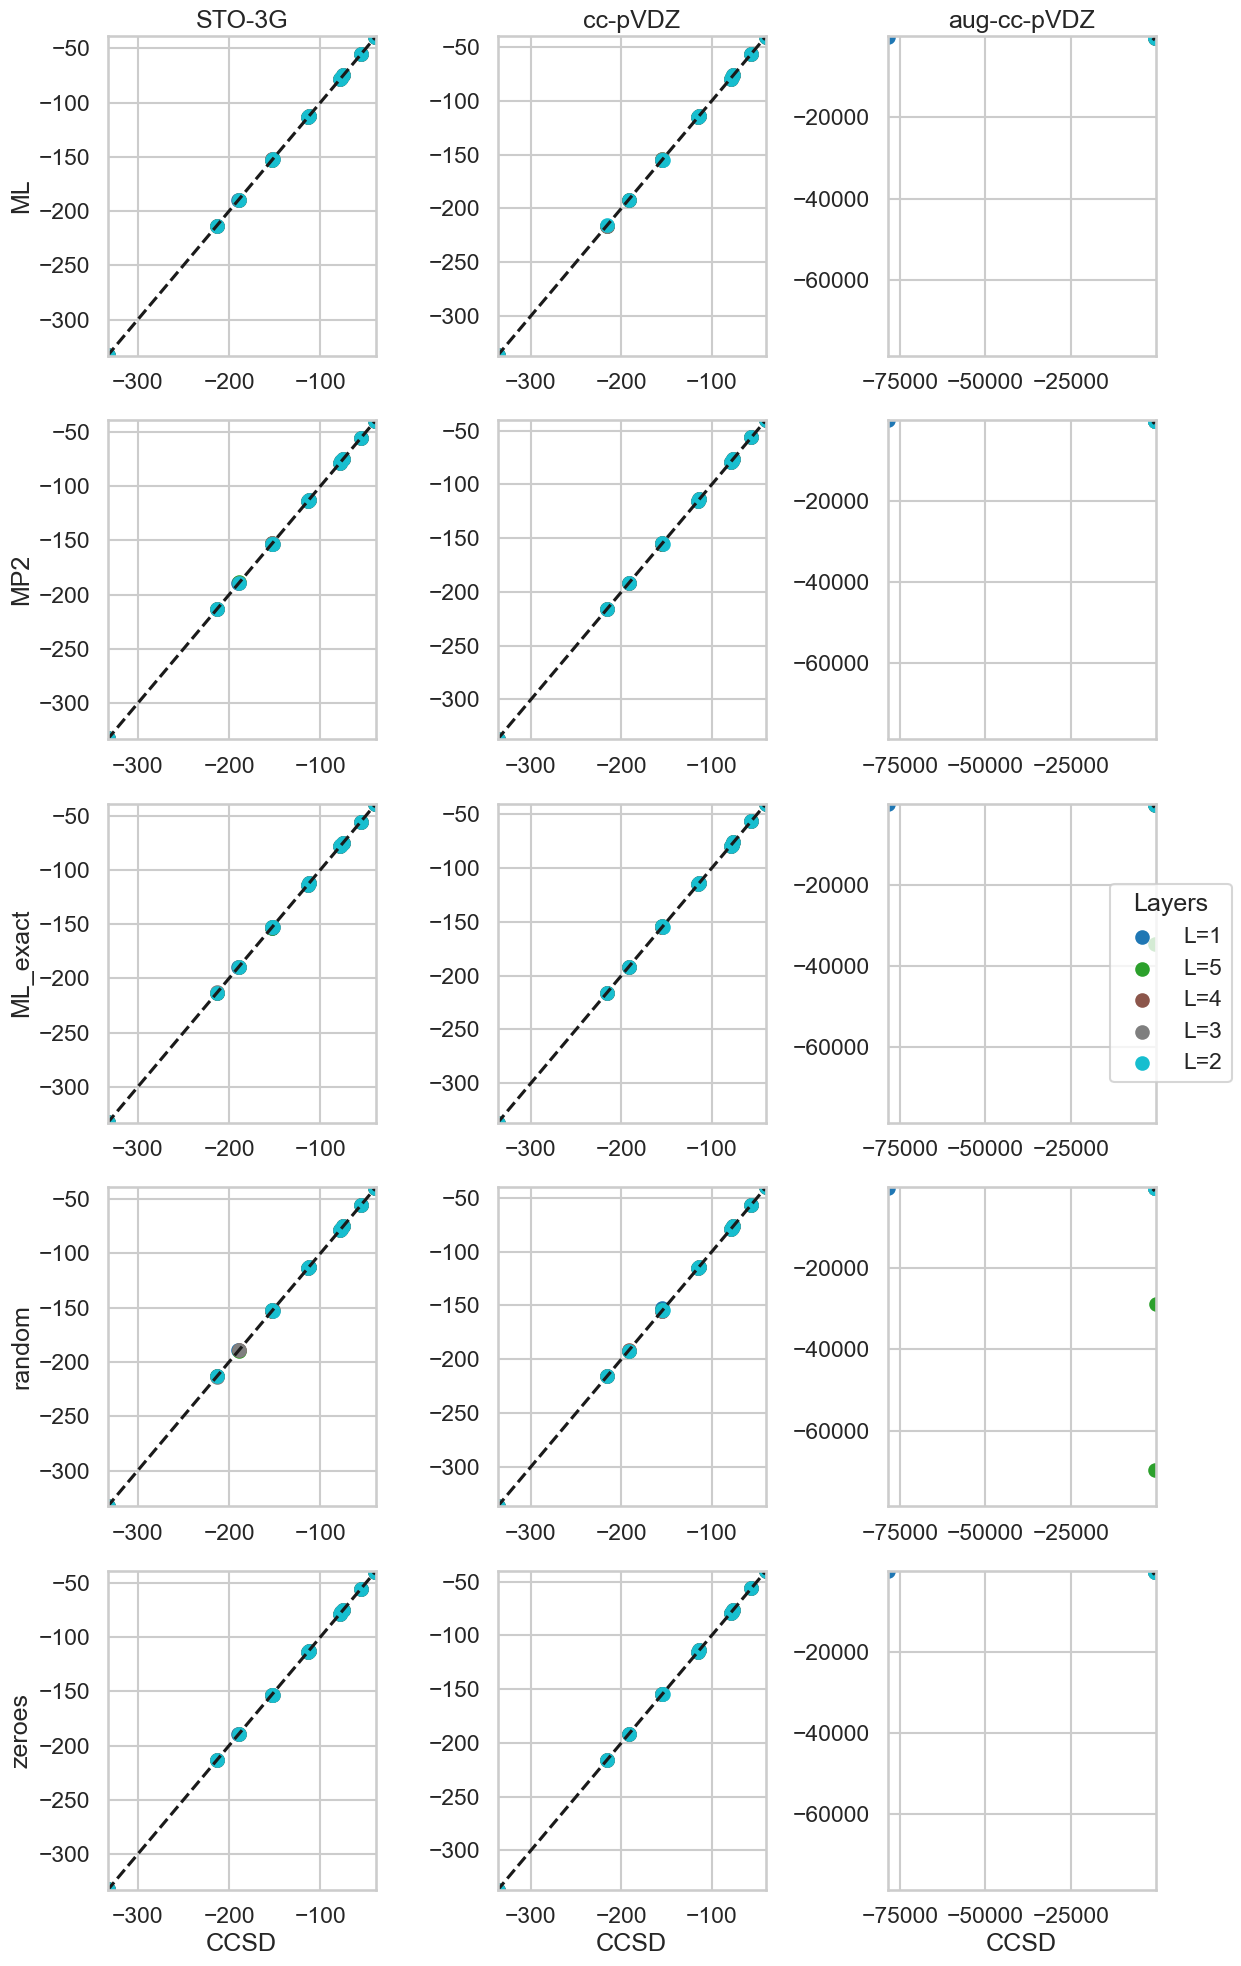

In [45]:
methods = uniqueInj[uniqueInj != 'CCSD']
n_rows = len(methods)
n_cols = len(uniqueBasis)
colors = plt.cm.tab10(np.linspace(0, 1, len(uniqueLayers)))
layer_color = dict(zip(uniqueLayers, colors))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

stats = []
added_labels = set()  # Fix #2: track labels to avoid duplicates

for (i, method), (j, basis) in product(enumerate(methods), enumerate(uniqueBasis)):
    ax = axes[i, j]
    all_ref, all_vals = [], []  # Fix #1: collect all data for axis limits

    for layers in uniqueLayers:
        ref_list, vals_list = [], []

        for mol in uniqueMol:
            mask = (
                (LUCJDF['Basis Set'] == basis) &
                (LUCJDF['L'] == layers) &
                (LUCJDF['Molecule'] == mol)
            )
            ref = LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].values
            vals = LUCJDF.loc[(LUCJDF['Injected'] == method) & mask, 'Energy'].values

            if len(ref) == 0 or len(vals) == 0 or len(ref) != len(vals):  # Fix #3
                continue

            ref_list.extend(ref)
            vals_list.extend(vals)

        if not ref_list:
            continue

        ref_arr = np.array(ref_list)
        vals_arr = np.array(vals_list)
        all_ref.extend(ref_arr)
        all_vals.extend(vals_arr)

        label = f'L={layers}'
        ax.scatter(
            ref_arr, vals_arr,
            color=layer_color[layers],
            label=label if label not in added_labels else None  # Fix #2
        )
        added_labels.add(label)
        stats.append((method, basis, mean_absolute_error(ref_arr, vals_arr)))

    ax.plot(range(-1000, 1000), range(-1000, 1000), 'k--')

    if all_ref:  # Fix #1: use aggregated data for limits
        ax.set_xlim(np.floor(min(all_ref)), np.ceil(max(all_ref)))
        ax.set_ylim(np.floor(min(all_ref)), np.ceil(max(all_ref)))

    if i == 0: ax.set_title(basis)
    if j == 0: ax.set_ylabel(method)
    if i == n_rows - 1: ax.set_xlabel('CCSD')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Layers', loc='center right', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
plt.show()

In [41]:
LUCJDF.loc[LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].index]

,Basis Set,Molecule,Method,L,Injected,Energy,Deviation,n_atoms
108,STO-3G,fluoroform,LUCJ(L=3),3,CCSD,-332.225473,0.0,5
110,STO-3G,ammonia,LUCJ(L=4),4,CCSD,-55.519929,0.0,4
597,aug-cc-pVDZ,ammonia,LUCJ(L=2),2,CCSD,-56.205309,0.0,4
720,STO-3G,(Z)-1-fluoroprop-1-ene,LUCJ(L=5),5,CCSD,-213.319735,0.0,9
801,aug-cc-pVDZ,water,LUCJ(L=3),3,CCSD,-76.040982,0.0,3
865,cc-pVDZ,ethylene,LUCJ(L=5),5,CCSD,-78.078765,0.0,6
924,cc-pVDZ,formaldehyde,LUCJ(L=3),3,CCSD,-113.914289,0.0,4
956,aug-cc-pVDZ,fluoroform,LUCJ(L=4),4,CCSD,-336.812912,0.0,5
1033,STO-3G,(Z)-1-fluoroprop-1-ene,LUCJ(L=3),3,CCSD,-213.322682,0.0,9


<Axes: xlabel='Deviation', ylabel='Density'>

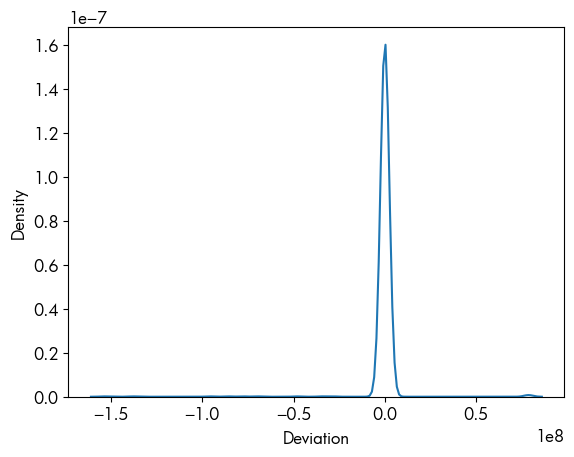

In [12]:
sns.kdeplot(LUCJDF['Deviation'])

In [13]:
stats

[('ML', 'STO-3G', 71.79159397070815),
 ('ML', 'STO-3G', 90.45033569782895),
 ('ML', 'STO-3G', 100.69461882333509),
 ('ML', 'STO-3G', 81.64263171990835),
 ('ML', 'STO-3G', 78.03040360818221),
 ('ML', 'cc-pVDZ', 101.558452740612),
 ('ML', 'cc-pVDZ', 39.55363576575406),
 ('ML', 'cc-pVDZ', 71.90841249860878),
 ('ML', 'cc-pVDZ', 6579.110291146714),
 ('ML', 'cc-pVDZ', 95.57467895087223),
 ('ML', 'aug-cc-pVDZ', 6634.340628059975),
 ('ML', 'aug-cc-pVDZ', 95.3791565378841),
 ('ML', 'aug-cc-pVDZ', 84.7284027726473),
 ('ML', 'aug-cc-pVDZ', 43.97406462661734),
 ('ML', 'aug-cc-pVDZ', 95.4097089507087),
 ('MP2', 'STO-3G', 99.6465979666001),
 ('MP2', 'STO-3G', 93.7422149105475),
 ('MP2', 'STO-3G', 55.39743403348789),
 ('MP2', 'STO-3G', 7266.4752940307735),
 ('MP2', 'STO-3G', 83.65285314517472),
 ('MP2', 'cc-pVDZ', 114.51443271414458),
 ('MP2', 'cc-pVDZ', 82.10101564725909),
 ('MP2', 'cc-pVDZ', 96.26084234777079),
 ('MP2', 'cc-pVDZ', 4063.8560624993534),
 ('MP2', 'cc-pVDZ', 101.21384307707983),
 ('MP2

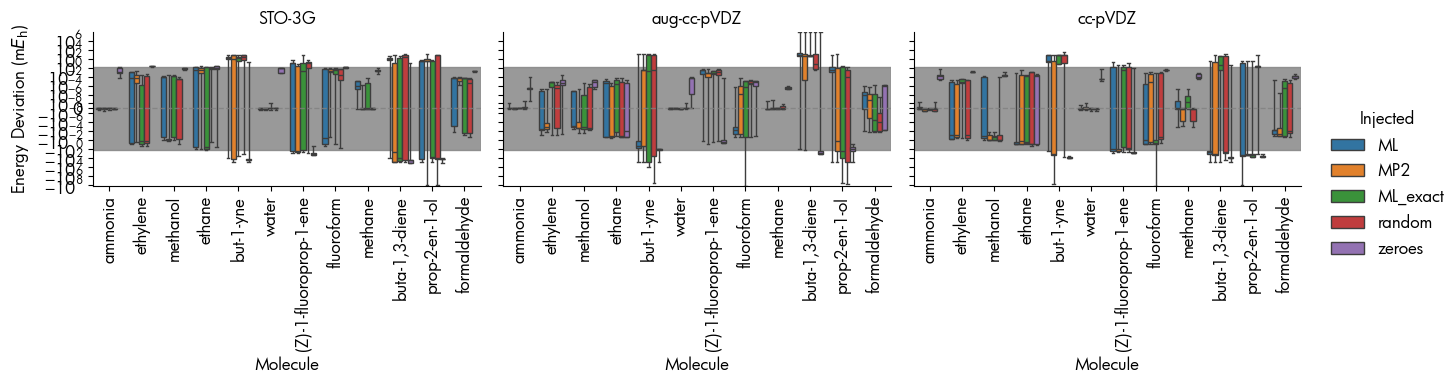

In [14]:
g = sns.catplot(LUCJDF[LUCJDF['Injected']!='CCSD'],
                col='Basis Set',
                # col='L',
                x='Molecule',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.1 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()

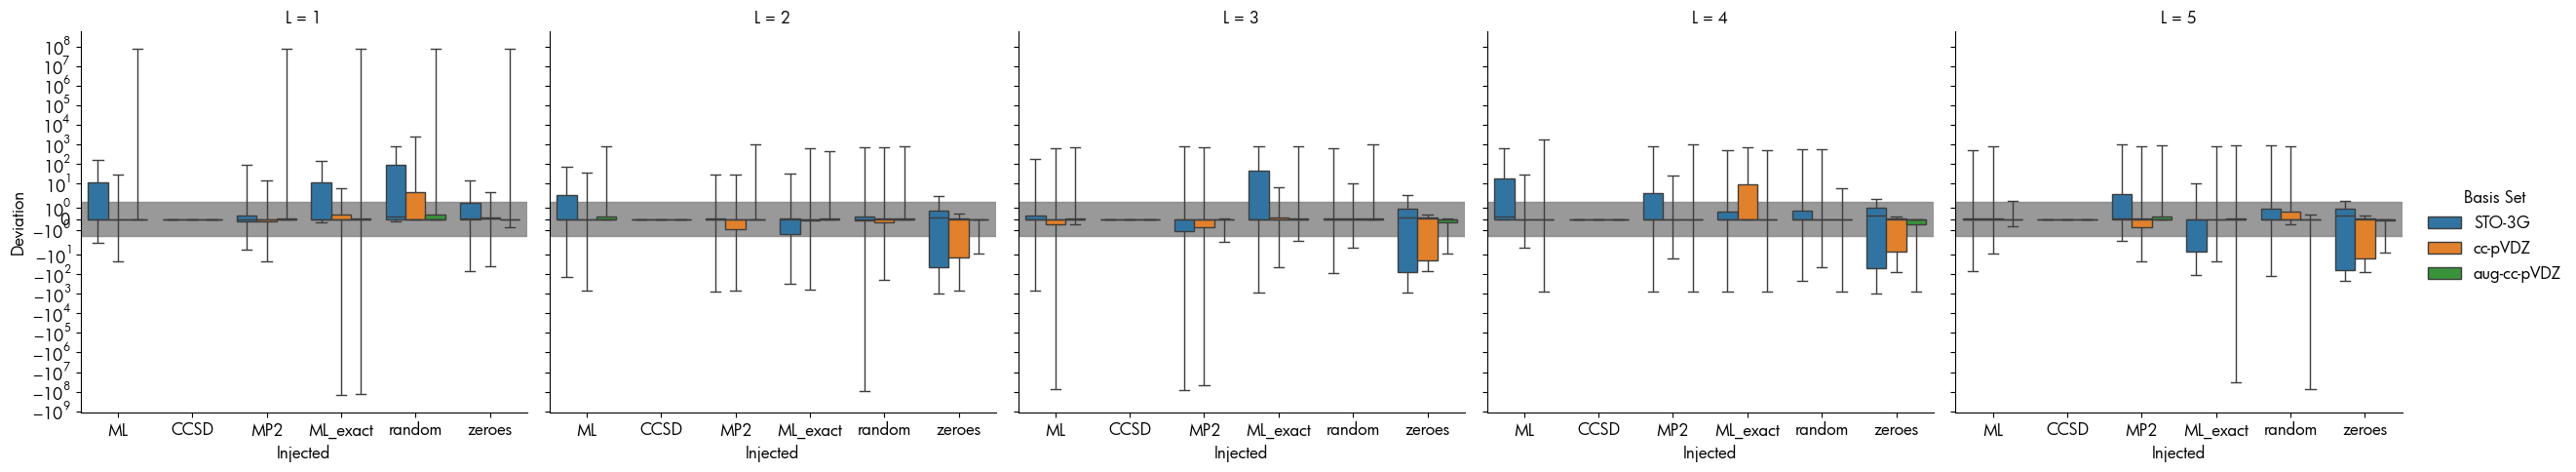

In [15]:
g = sns.catplot(data=LUCJDF, y='Deviation', x='Injected', hue='Basis Set', col='L', kind='box',
                whis=(0, 100))  # or whis=np.inf

for ax in g.axes.flat:
    ax.set_yscale('symlog')
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)

In [16]:
LUCJDF['Molecule'].unique()

array(['ammonia', 'ethylene', 'methanol', 'ethane', 'but-1-yne', 'water',
       '(Z)-1-fluoroprop-1-ene', 'fluoroform', 'methane',
       'buta-1,3-diene', 'prop-2-en-1-ol', 'formaldehyde'], dtype=object)

In [17]:
LUCJDF['Deviation'].describe()

count    1.080000e+03
mean    -3.132609e+05
std      9.863749e+06
min     -1.535158e+08
25%     -2.742092e-04
50%      0.000000e+00
75%      7.375468e-03
max      7.854208e+07
Name: Deviation, dtype: float64

# Stack all data

In [18]:
for a,b in moldf[['molecule','mol_filename']].values:
    if 'GDB' in b:
        name = b.replace('.xyz','')
        energyDF['Molecule'] = energyDF['Molecule'].replace(name,a)

In [19]:
energyDF['L'] = len(energyDF)*[np.nan]
energyDF['Injected'] = len(energyDF)*[np.nan]

In [20]:
upDF = pd.concat([energyDF,LUCJDF]).reset_index().drop(columns=['index'])
upDF['Deviation'] = np.nan

In [21]:
moldf

,molecule,formula,mol_filename,num_orbitals,n_electrons
0,ammonia,NH3,ammonia157.xyz,8,10
1,methane,CH4,methane50.xyz,9,10
2,ethylene,C2H4,ethylene42.xyz,14,16
3,ethane,C2H6,ethane28.xyz,16,18
4,water,H2O,water183.xyz,7,10
5,formaldehyde,CH20,formaldehyde138.xyz,12,16
6,methanol,CH3OH,methanol22.xyz,14,18
7,fluoroform,CHF3,GDB04_5.xyz,21,34
8,"buta-1,3-diene",C4H6,GDB04_53.xyz,26,30
9,but-1-yne,C4H6,GDB04_49.xyz,26,30


In [22]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4,
    "prop-2-en-1-ol":10,
    "but-1-yne":10,
    "fluoroform":5,
    "buta-1,3-diene":10,
    "(Z)-1-fluoroprop-1-ene":9
}

upDF['n_atoms'] = upDF['Molecule'].map(n_atoms_dict)

In [23]:
upDF.sort_values(by=['n_atoms'])

,Basis Set,Molecule,Method,Energy,L,Injected,Deviation,n_atoms
0,STO-3G,water,HF,-74.960552,NaN,NaN,NaN,3
797,aug-cc-pVDZ,water,LUCJ(L=1),-76.040982,1.0,zeroes,NaN,3
794,aug-cc-pVDZ,water,LUCJ(L=1),-76.040982,1.0,random,NaN,3
774,STO-3G,water,LUCJ(L=4),-75.009479,4.0,ML_exact,NaN,3
770,cc-pVDZ,water,LUCJ(L=4),-76.031884,4.0,ML_exact,NaN,3
...,...,...,...,...,...,...,...,...
671,STO-3G,but-1-yne,LUCJ(L=1),-153.293473,1.0,CCSD,NaN,10
669,aug-cc-pVDZ,"buta-1,3-diene",LUCJ(L=5),-154.472871,5.0,ML_exact,NaN,10
156,aug-cc-pVDZ,but-1-yne,LUCJ(L=1),-164.504840,1.0,ML_exact,NaN,10
131,aug-cc-pVDZ,but-1-yne,SHCI,-155.149598,NaN,NaN,NaN,10


# Deviation from CASCI

In [24]:
exact = upDF[(upDF['Method'] == 'CASCI')].dropna(subset=['Energy'])
exactavail = LUCJDF[LUCJDF.Molecule.isin(exact.Molecule.unique())].copy()
exactavail['Deviation'] = np.nan

In [25]:
for basis, mol, layer, inj in product(uniqueBasis,exact['Molecule'].unique(),uniqueLayers,uniqueInj):
    mask = (exact['Basis Set'] == basis) & (exact['Molecule'] == mol)
    found_mask = (exactavail['Basis Set'] == basis) & (exactavail['Molecule'] == mol) & (exactavail['Injected'] == inj) & (exactavail['L'] == layer)
    print(exactavail.loc[found_mask,'Energy'].values[0] - exact.loc[mask,'Energy'].values[0])
    exactavail.loc[found_mask,'Deviation']= (exactavail.loc[found_mask,'Energy'].values[0] - exact.loc[mask,'Energy'].values[0])*1e3
    

-4.163780431554187e-11
-4.3371528590796515e-11
-4.46789272245951e-11
-4.285993782104924e-11
-4.263256414560601e-11
5.5711000896963014e-05
-4.4508396968012676e-11
-4.440892098500626e-11
-4.4508396968012676e-11
-4.348521542851813e-11
-4.4295234147284646e-11
0.0009081891426063748
-4.3925751924689393e-11
-4.531841568677919e-11
-4.347100457380293e-11
-4.341416115494212e-11
-4.375522166810697e-11
0.0009082820047723317
-4.433786671143025e-11
-4.0671466194908135e-11
-4.462208380573429e-11
-4.4721559788740706e-11
-4.3215209188929293e-11
5.9475822610011164e-05
-4.5844217311241664e-11
-4.3797854232252575e-11
-4.384048679639818e-11
-2.8904878490720876e-11
-4.348521542851813e-11
0.000861867200583788
-2.2183144210430328e-11
-2.2751578399038408e-11
-2.2311041902867146e-11
-2.1941559680271894e-11
-2.2865265236760024e-11
4.065864416702425e-06
-2.1756818568974268e-11
-2.1799451133119874e-11
-2.2367885321727954e-11
-2.1387336346379016e-11
-2.2922108655620832e-11
0.0015509668311466385
-2.2822632672614418e

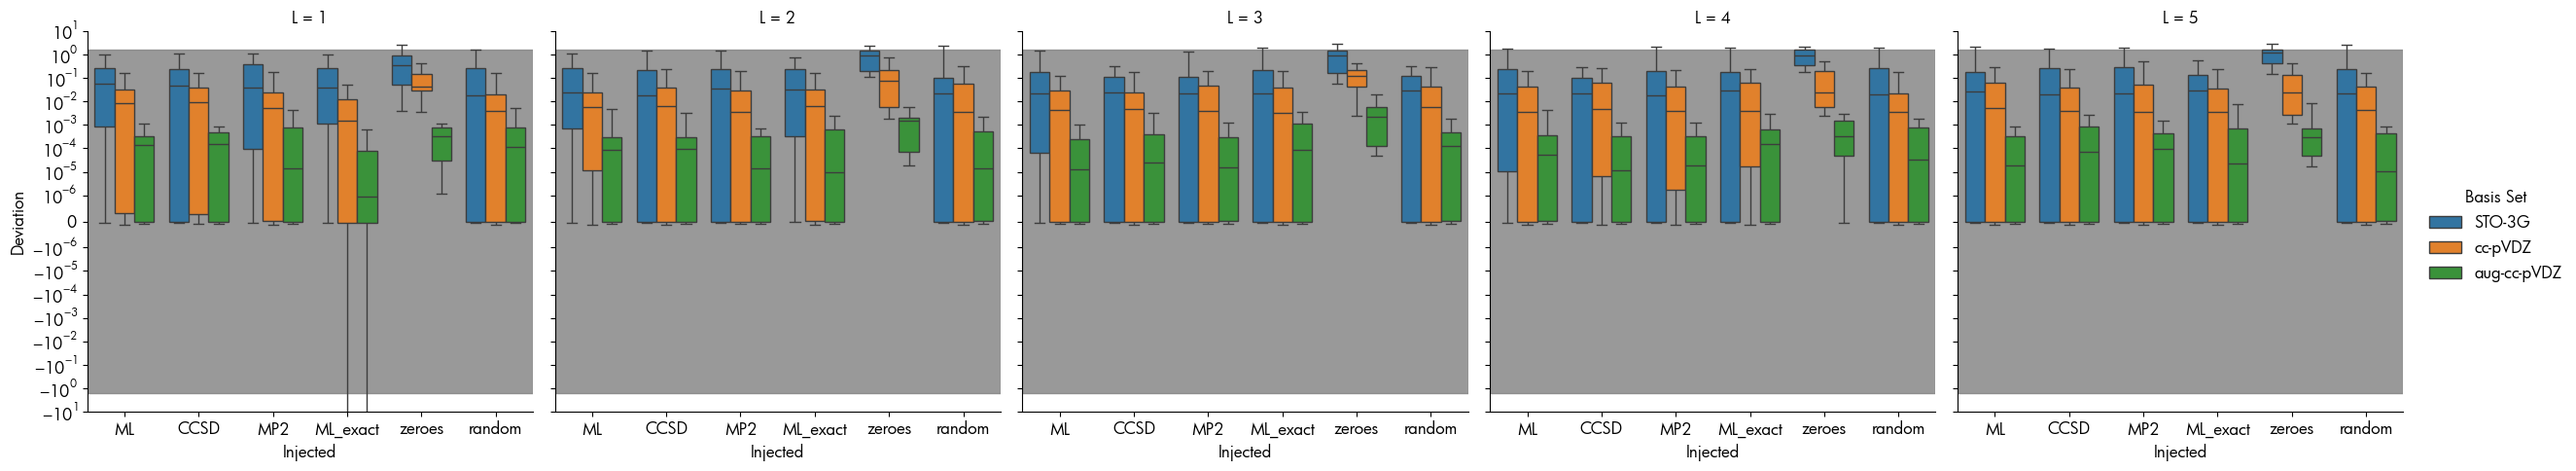

In [26]:
g = sns.catplot(data=exactavail, y='Deviation', x='Injected', hue='Basis Set', col='L', kind='box',
                whis=(0, 100))  # or whis=np.inf

for ax in g.axes.flat:
    ax.set_yscale('symlog',linthresh=1e-6)
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    ax.set_ylim(-10**1,10**1)
    

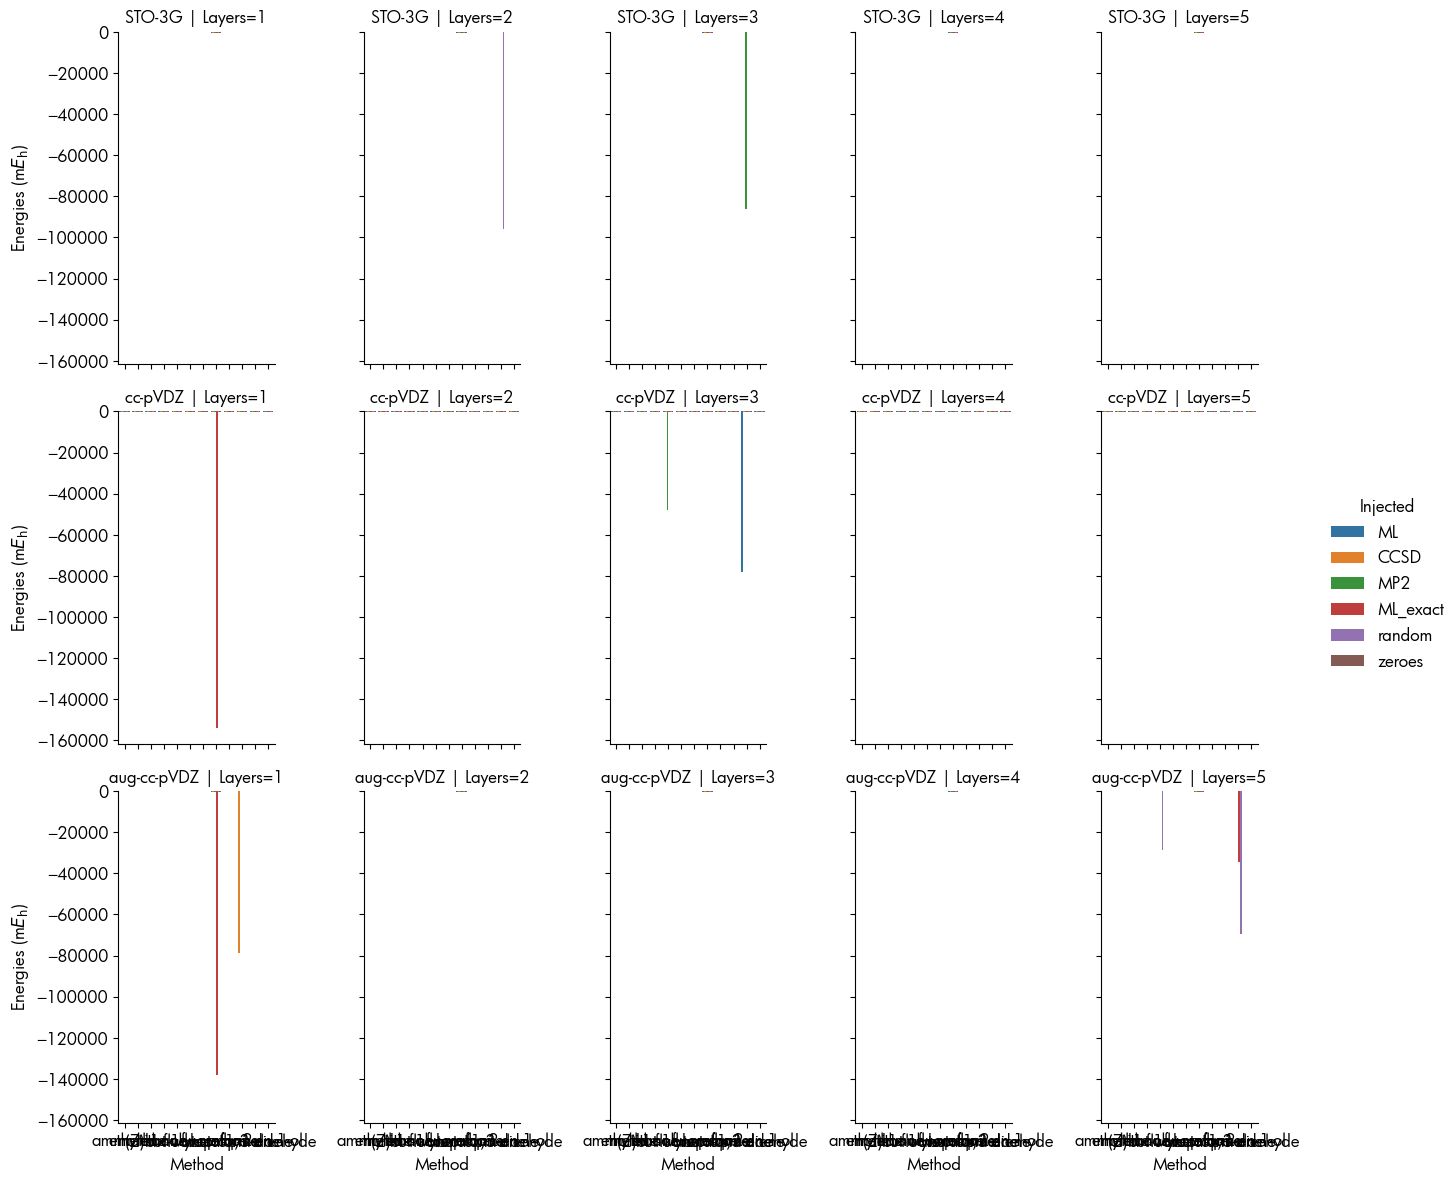

In [27]:
g = sns.catplot(LUCJDF,
                row='Basis Set',
                col='L',
                x='Molecule',
                y='Energy',
                hue='Injected',
                kind='bar',
                height=4,
                aspect=0.6,
                )

# Adjust titles and axis labels
g.set_titles(col_template="Layers={col_name}", row_template="{row_name}")
g.set_axis_labels("Method", r"Energies (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()

In [28]:
refmethod = "CASCI"
for mol in uniqueMol:
    for basis in uniqueBasis:
        # Get the CASCI reference energy (scalar)
        casci_row = upDF.loc[
            (upDF["Molecule"] == mol)
            & (upDF["Method"] == refmethod)
            & (upDF["Basis Set"] == basis),
            "Energy",
        ]
        if casci_row.empty:
            continue  # skip if no CASCI reference for this (mol, basis)
        casci_e = casci_row.values[0]  # extract scalar

        # Compute deviations for other methods with the same mol/basis
        mask = (
            (upDF["Molecule"] == mol)
            & (upDF["Basis Set"] == basis)
            # & (upDF["Method"] != refmethod)
        )
        # print(upDF.loc[mask, "Energy"]- casci_e)
        upDF.loc[mask, "Deviation"] = (upDF.loc[mask, "Energy"] - casci_e)*1e3
        # print(upDF.loc[mask, "Energy"] - casci_e)

In [29]:
#sns.relplot(data=upDF, x="total_bill", y="tip", hue="day", col="time", row="sex")

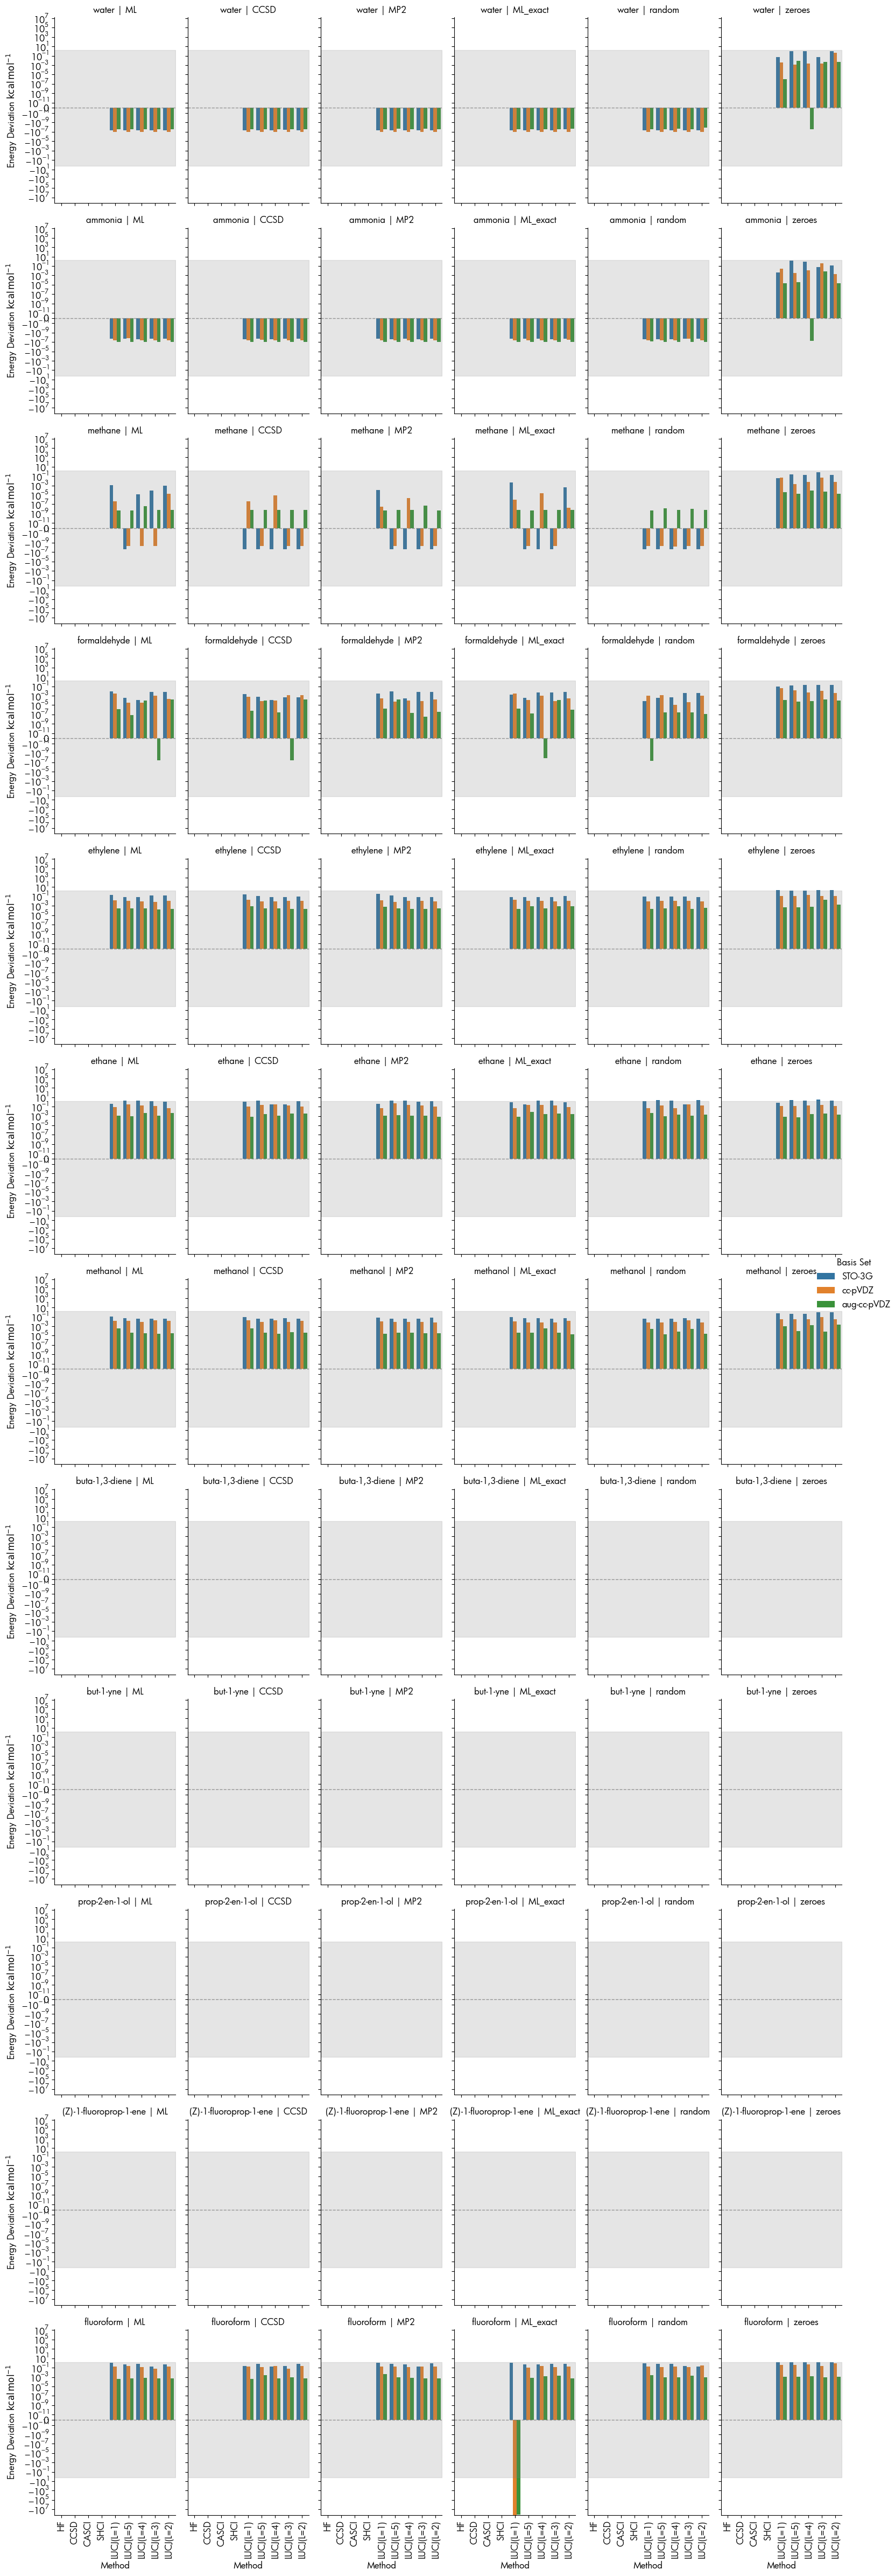

In [30]:
# Create the FacetGrid with bar plots
g = sns.catplot(
    data=upDF,
    row="Molecule",
    y="Deviation",
    x="Method",
    hue="Basis Set",
    col="Injected",
    kind="bar",
    height=4,
    aspect=0.6,
)

# Compute global deviation range for consistent shading/scaling
ymin = upDF["Deviation"].min()
ymax = upDF["Deviation"].max()
pad = 0.1 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-11)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # Gray fill region across same y-span
    ax.fill_between(
        np.linspace(-0.5, len(upDF["Method"].unique()) - 0.5, 100),
        -1.6, 1.6,
        color="gray", alpha=0.2
    )

    ax.set_xlim(-0.5, len(upDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Method", r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()


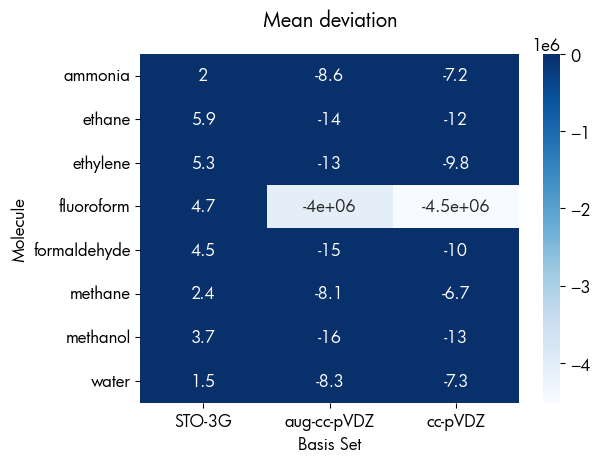

In [31]:
heatmap_data = upDF.pivot_table(values='Deviation', index='Molecule', columns='Basis Set', aggfunc='mean') # here aggfunc mean computes the mean deviation
sns.heatmap(heatmap_data, annot=True, cmap='Blues')
plt.title('Mean deviation', pad=20)
plt.tight_layout()
plt.show()

In [32]:
upDF.head()

,Basis Set,Molecule,Method,Energy,L,Injected,Deviation,n_atoms
0,STO-3G,water,HF,-74.960552,NaN,NaN,48.926714,3
1,STO-3G,water,CCSD,-75.009350,NaN,NaN,0.129131,3
2,STO-3G,water,CASCI,-75.009479,NaN,NaN,0.000000,3
3,STO-3G,water,SHCI,-75.009474,NaN,NaN,0.005023,3
4,STO-3G,ammonia,HF,-55.454318,NaN,NaN,65.611397,4


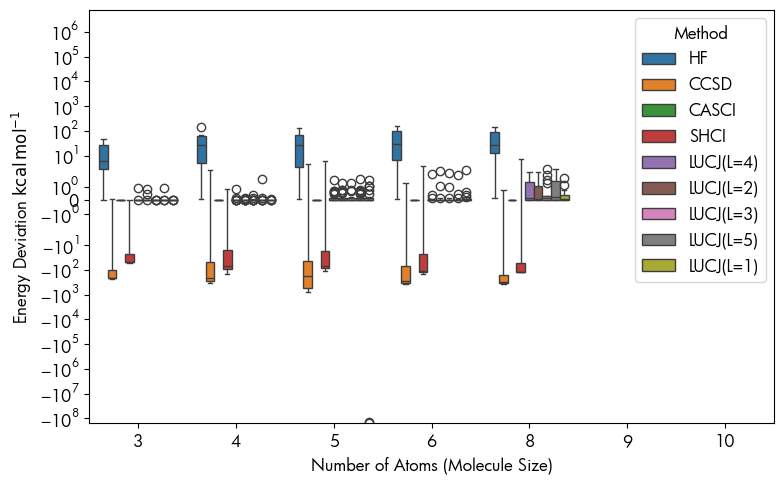

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method'
)
plt.yscale('symlog')
plt.xlabel("Number of Atoms (Molecule Size)")

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.tight_layout()
plt.show()


/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_19784/482701201.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(


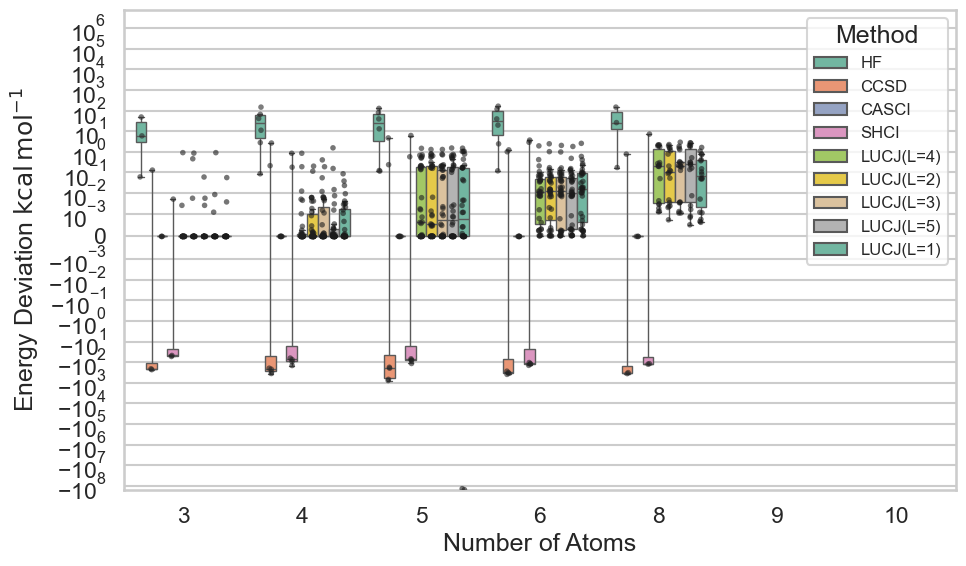

In [34]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method',
    palette='Set2',
    fliersize=0 
)
sns.stripplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method',
    dodge=True,
    color='k',
    alpha=0.6,
    size=4
)

plt.yscale('symlog', linthresh=1e-3)
plt.xlabel("Number of Atoms")
plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(uniqueMethods)], labels[:len(uniqueMethods)], title="Method", fontsize=12)

plt.tight_layout()
plt.show()

In [35]:
upDF

,Basis Set,Molecule,Method,Energy,L,Injected,Deviation,n_atoms
0,STO-3G,water,HF,-74.960552,NaN,NaN,4.892671e+01,3
1,STO-3G,water,CCSD,-75.009350,NaN,NaN,1.291311e-01,3
2,STO-3G,water,CASCI,-75.009479,NaN,NaN,0.000000e+00,3
3,STO-3G,water,SHCI,-75.009474,NaN,NaN,5.023047e-03,3
4,STO-3G,ammonia,HF,-55.454318,NaN,NaN,6.561140e+01,4
...,...,...,...,...,...,...,...,...
1219,STO-3G,methane,LUCJ(L=3),-39.806157,3.0,MP2,-2.367528e-08,5
1220,STO-3G,methanol,LUCJ(L=5),-113.662553,5.0,ML_exact,5.608108e-02,6
1221,cc-pVDZ,ammonia,LUCJ(L=3),-56.206728,3.0,random,-1.800515e-08,4
1222,cc-pVDZ,formaldehyde,LUCJ(L=4),-113.914290,4.0,ML,3.630275e-05,4


/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_19784/2643362325.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(


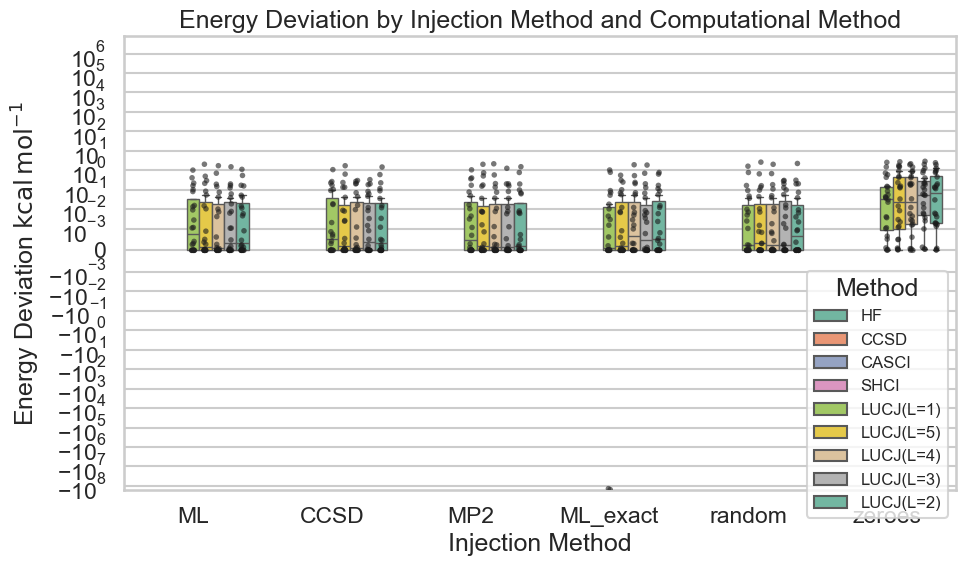

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=upDF,
    x='Injected',      # categorical injection method
    y='Deviation',
    hue='Method',
    palette='Set2',
    fliersize=0
)
sns.stripplot(
    data=upDF,
    x='Injected',
    y='Deviation',
    hue='Method',
    dodge=True,
    color='k',
    alpha=0.6,
    size=4
)

plt.yscale('symlog', linthresh=1e-3)
plt.xlabel("Injection Method")
plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.title("Energy Deviation by Injection Method and Computational Method")

# Simplify legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(uniqueMethods)], labels[:len(uniqueMethods)], title="Method", fontsize=12, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

/Users/grierjones/miniconda3/envs/distributed_LUCJ/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 62.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/grierjones/miniconda3/envs/distributed_LUCJ/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 92.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/grierjones/miniconda3/envs/distributed_LUCJ/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 93.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


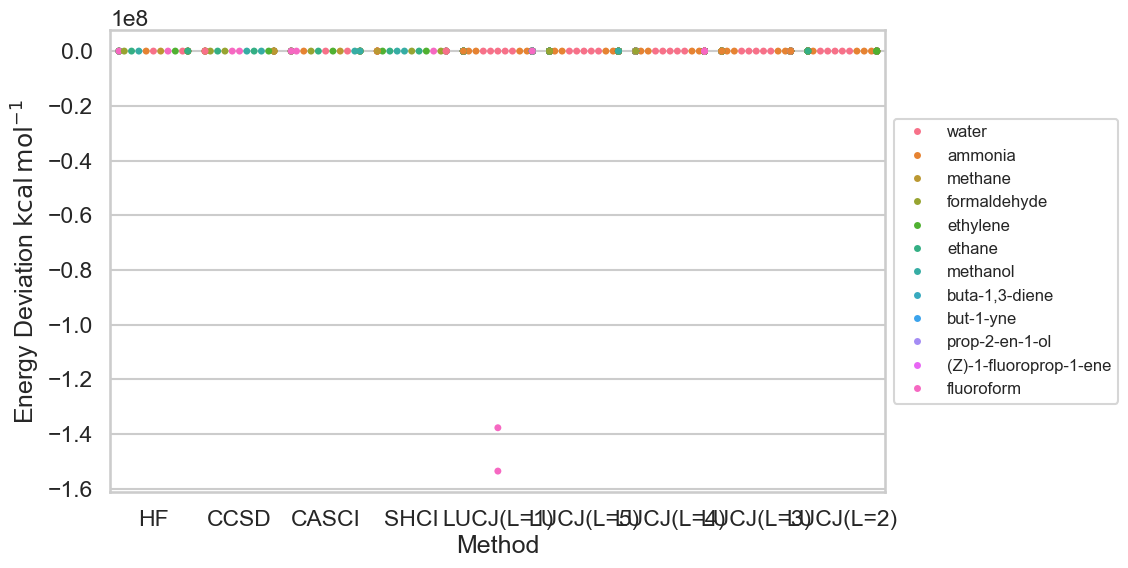

In [37]:
plt.figure(figsize=(10, 6))
sns.swarmplot(
    data=upDF,
    x='Method',
    y='Deviation',
    hue='Molecule'
)

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.show()

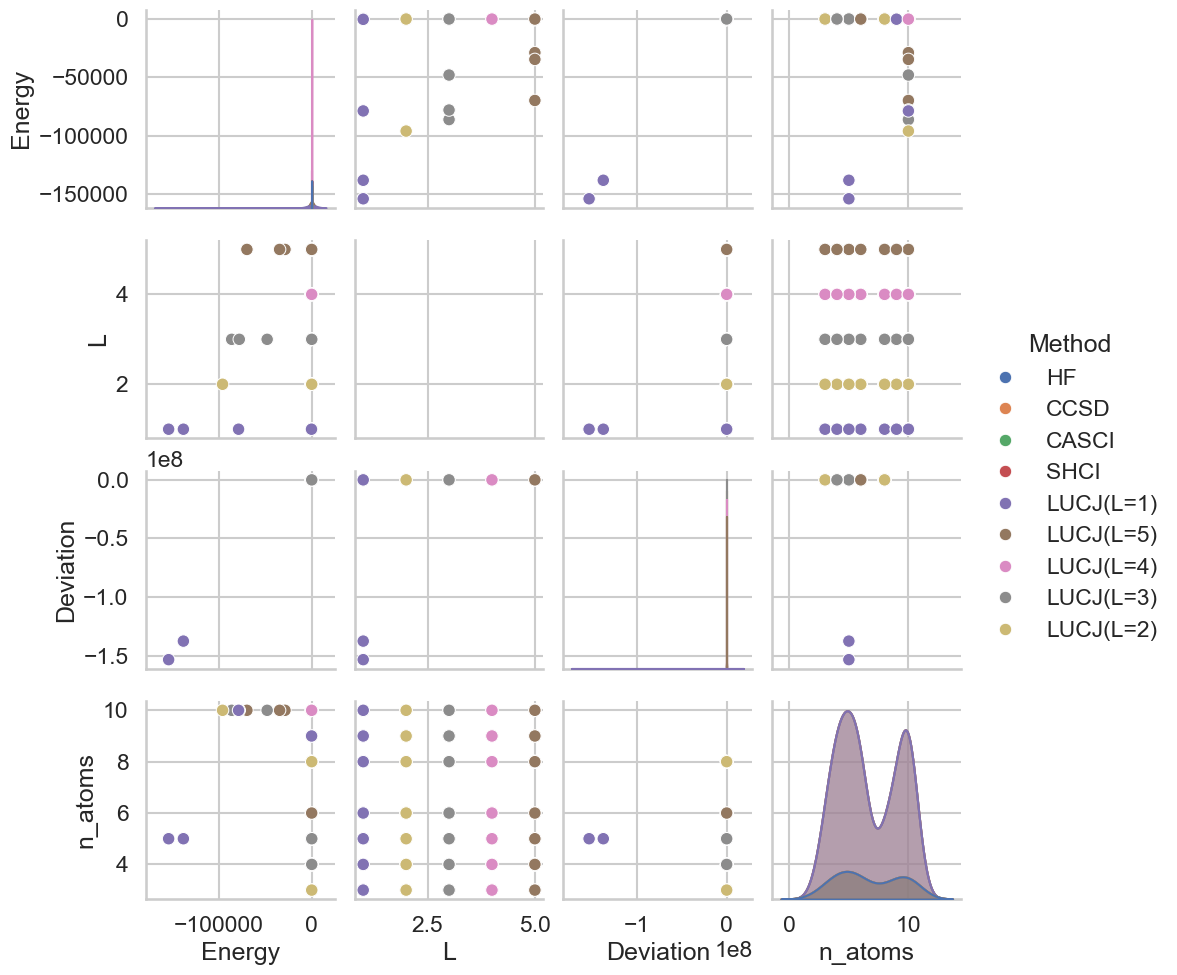

In [38]:
sns.pairplot(upDF, hue="Method")